In [1]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np

In [2]:
model = pybamm.lithium_ion.SPMe()
sim = pybamm.Simulation(model)
sim.solve([0, 3600])

# Accessing solution variables

In [3]:
# extract the solution object by:
solution = sim.solution

# or
solution = sim.solve([0, 3600])

In [4]:
t = solution["Time [s]"]
V = solution["Voltage [V]"]

In [5]:
# check whole variable values
V.entries

array([3.77081317, 3.77079279, 3.77077254, 3.77073231, 3.77065324,
       3.77049952, 3.77021771, 3.76995259, 3.76947399, 3.76903603,
       3.76863064, 3.76787865, 3.7672045 , 3.76600987, 3.76506801,
       3.76420935, 3.76341241, 3.76266442, 3.7612911 , 3.76004184,
       3.7588895 , 3.7578216 , 3.75682942, 3.75503565, 3.75344643,
       3.75201702, 3.75071602, 3.74952015, 3.74841036, 3.74737186,
       3.74546111, 3.74388578, 3.74210993, 3.74059926, 3.73914878,
       3.73774197, 3.73636906, 3.73502304, 3.73369936, 3.73110466,
       3.72857096, 3.7260876 , 3.72125552, 3.7171124 , 3.71309641,
       3.70921096, 3.70545836, 3.70183936, 3.69500063, 3.688684  ,
       3.68286921, 3.67752799, 3.67262547, 3.66396455, 3.65641393,
       3.63864846, 3.59791633, 3.48889622, 3.17239789])

In [6]:
# Check whole variable values
t.entries

array([0.00000000e+00, 1.23792596e-02, 2.47585193e-02, 4.95170385e-02,
       9.90340771e-02, 1.98068154e-01, 3.96136308e-01, 5.94204462e-01,
       9.90340771e-01, 1.38647708e+00, 1.78261339e+00, 2.57488600e+00,
       3.36715862e+00, 4.95170385e+00, 6.37779456e+00, 7.80388527e+00,
       9.22997598e+00, 1.06560667e+01, 1.35082481e+01, 1.63604295e+01,
       1.92126109e+01, 2.20647924e+01, 2.49169738e+01, 3.06213366e+01,
       3.63256995e+01, 4.20300623e+01, 4.77344251e+01, 5.34387880e+01,
       5.91431508e+01, 6.48475137e+01, 7.62562393e+01, 8.65240924e+01,
       9.89736408e+01, 1.10178234e+02, 1.21382828e+02, 1.32587421e+02,
       1.43792015e+02, 1.54996608e+02, 1.66201202e+02, 1.88610389e+02,
       2.11019576e+02, 2.33428763e+02, 2.78247137e+02, 3.17930983e+02,
       3.57614829e+02, 3.97298675e+02, 4.36982521e+02, 4.76666368e+02,
       5.56034060e+02, 6.35401752e+02, 7.14769445e+02, 7.94137137e+02,
       8.73504829e+02, 1.03224021e+03, 1.19097560e+03, 1.50844637e+03,
      

In [7]:
# Check the variable values at specific times
V([0, 400, 780, 1236])  # times in seconds

array([3.77081317, 3.70895128, 3.67844618, 3.65435734])

# Observing custom variables from the solution

In [8]:
# View all OUTPUT variables in the model.
model.variables

{'Time [s]': Time(0x278c45811968c9f8, time, children=[], domains={}),
 'Time [min]': Multiplication(0x731e6d5a2317b7e0, *, children=['0.016666666666666666', 'time'], domains={}),
 'Time [h]': Multiplication(0x6ce3391a61914966, *, children=['0.0002777777777777778', 'time'], domains={}),
 'x [m]': SpatialVariable(-0x7b22622cf4ad0246, x, children=[], domains={'primary': ['negative electrode', 'separator', 'positive electrode'], 'secondary': ['current collector']}),
 'x_n [m]': SpatialVariable(0x2ee6e10b2332879, x_n, children=[], domains={'primary': ['negative electrode'], 'secondary': ['current collector']}),
 'x_s [m]': SpatialVariable(-0x596f8c8e27dfd416, x_s, children=[], domains={'primary': ['separator'], 'secondary': ['current collector']}),
 'x_p [m]': SpatialVariable(-0x78eee202c6408d8a, x_p, children=[], domains={'primary': ['positive electrode'], 'secondary': ['current collector']}),
 'r_n [m]': SpatialVariable(-0x653e94602300b23, r_n, children=[], domains={'primary': ['negative 

In [9]:
model.variables.search("Voltage")

Results for 'Voltage': ['Local voltage [V]', 'Voltage expression [V]', 'Terminal voltage [V]', 'Voltage [V]', 'Surface open-circuit voltage [V]', 'Bulk open-circuit voltage [V]', 'Battery open-circuit voltage [V]', 'Battery voltage [V]']


Text(0, 0.5, 'Conductance [S]')

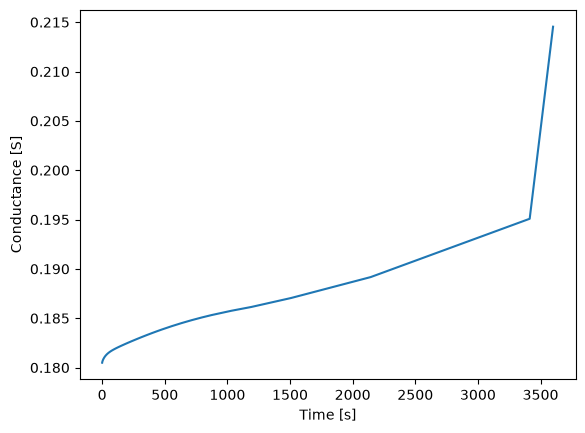

In [10]:
# Calculate extra variable that are not included in the model output. For example, conductance = current / voltage.
t = solution["Time [s]"].entries
conductance = solution["Current [A]"].entries / solution["Voltage [V]"].entries

plt.plot(t, conductance)
plt.xlabel("Time [s]")
plt.ylabel("Conductance [S]")

In [11]:
# PyBaMM’s solver uses adaptive time stepping, so the saved solver times are uneven. to overview the time steps:
t = solution["Time [s]"].entries
dt = np.diff(t)

print(dt)
print("Number of saved points:", len(t))
print("Min dt [s]:", dt.min())
print("Max dt [s]:", dt.max())
print("Mean dt [s]:", dt.mean())

[1.23792596e-02 1.23792596e-02 2.47585193e-02 4.95170385e-02
 9.90340771e-02 1.98068154e-01 1.98068154e-01 3.96136308e-01
 3.96136308e-01 3.96136308e-01 7.92272616e-01 7.92272616e-01
 1.58454523e+00 1.42609071e+00 1.42609071e+00 1.42609071e+00
 1.42609071e+00 2.85218142e+00 2.85218142e+00 2.85218142e+00
 2.85218142e+00 2.85218142e+00 5.70436284e+00 5.70436284e+00
 5.70436284e+00 5.70436284e+00 5.70436284e+00 5.70436284e+00
 5.70436284e+00 1.14087257e+01 1.02678531e+01 1.24495483e+01
 1.12045935e+01 1.12045935e+01 1.12045935e+01 1.12045935e+01
 1.12045935e+01 1.12045935e+01 2.24091870e+01 2.24091870e+01
 2.24091870e+01 4.48183740e+01 3.96838462e+01 3.96838462e+01
 3.96838462e+01 3.96838462e+01 3.96838462e+01 7.93676923e+01
 7.93676923e+01 7.93676923e+01 7.93676923e+01 7.93676923e+01
 1.58735385e+02 1.58735385e+02 3.17470769e+02 6.34941538e+02
 1.26988308e+03 1.86729017e+02]
Number of saved points: 59
Min dt [s]: 0.012379259631594804
Max dt [s]: 1269.8830768678354
Mean dt [s]: 62.0689655

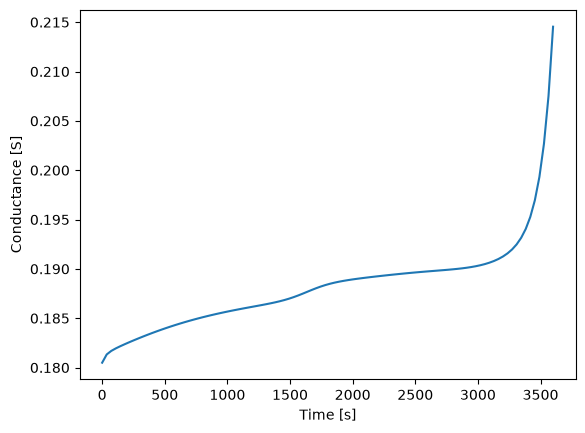

In [12]:
# plot a smoother curve by interpolating the solution
t = np.linspace(0, solution.t[-1], 100)     # create a new time grid with 100 steps

current = solution["Current [A]"](t)
voltage = solution["Voltage [V]"](t)

conductance = current / voltage

plt.plot(t, conductance)
plt.xlabel("Time [s]")
plt.ylabel("Conductance [S]")
plt.show()

# Saving the simulation and output data

## Saving the whole simulation

In [13]:
# save the simulation results for analyzing later w/o re-simulating. The file is saved in the root directory as "SPMe.pkl"
sim.save("SPMe.pkl")

In [14]:
# load and plot the stored simulation
sim2 = pybamm.load("SPMe.pkl")
sim2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

## Saving the solution

In [15]:
# alternatively, can just save the solution
sol = sim.solution
sol.save("SPMe_sol.pkl")

In [16]:
# load and plot the saved solution
sol2 = pybamm.load("SPMe_sol.pkl")
sol2.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=1.0, step=0.01), Output()), _dom_classes=('w…

## Saving specific data / variables

In [17]:
# Another way is to only save specific data / variables in .pkl format.
sol.save_data("sol_data.pkl", ["Current [A]", "Voltage [V]"])

In [18]:
# or save it in .csv format
sol.save_data("sol_data.csv", ["Time [s]", "Current [A]", "Voltage [V]"], to_format="csv")

# or in .mat format. Note that matlab needs names without spaces
sol.save_data(
    "sol_data.mat",
    ["Time [s]", "Current [A]", "Voltage [V]"],
    to_format="matlab",
    short_names={
        "Time [s]": "t",
        "Current [A]": "I",
        "Voltage [V]": "V",
    },
)

In [19]:
# remove the saved files to clean up the directory
import os

os.remove("SPMe.pkl")
os.remove("SPMe_sol.pkl")
os.remove("sol_data.pkl")
os.remove("sol_data.csv")
os.remove("sol_data.mat")